# What drives the price of a car?

![](images/kurt.jpeg)

## Overview

This notebook completes Practical Application 2 using the CRISP-DM framework. The business goal is to help a used-car dealership understand which vehicle characteristics are most associated with higher or lower prices.

Because the Craigslist vehicle dataset is very noisy, this analysis intentionally spends substantial effort on data cleaning and feature engineering before modeling. That cleaning work is central to making the final recommendations credible.

## CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>

The workflow follows the CRISP-DM stages: business understanding, data understanding, data preparation, modeling, evaluation, and deployment.

## Business Understanding

From a business perspective, the dealership wants to know what consumers appear to value in used cars so it can make better inventory, pricing, and merchandising decisions.

As a data problem, this is a supervised regression task. The target variable is `price`, a continuous dollar amount. The predictor variables include vehicle age, mileage, condition, title status, manufacturer, body type, fuel type, drivetrain, transmission, color, and geography. The goal is not only to minimize prediction error, but also to identify reliable price drivers that can be translated into dealer-facing recommendations.

In [1]:
# Set up the analysis environment and import the libraries used for data cleaning, visualization, preprocessing, modeling, and evaluation.
# Import libraries
from __future__ import annotations

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
CURRENT_YEAR = 2026
MODEL_SAMPLE_N = 200_000
DATA_PATH = Path("data/vehicles.csv")
timing_results = []


In [2]:
# Define a helper to collect runtime for the notebook's most expensive processing steps.
def record_timing(step: str, start_time: float) -> None:
    elapsed_seconds = time.perf_counter() - start_time
    timing_results.append({"step": step, "seconds": elapsed_seconds})
    print(f"{step} completed in {elapsed_seconds:,.1f} seconds")

In [3]:
# Load the used-car listings dataset and confirm the starting size before any cleaning.
# Load data
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]:,}")
raw.head()


Rows: 426,880
Columns: 18


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


## Data Understanding

The first pass checks data size, data types, missingness, suspicious target values, and category cardinality. These checks drive the cleaning plan rather than applying generic preprocessing blindly.

In [4]:
# Review column names, data types, and non-null counts to identify immediate quality issues.
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
# Measure missingness by column so cleaning choices are based on the data rather than assumptions.
missing = (
    raw.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)
missing


,missing_pct
size,71.77
cylinders,41.62
condition,40.79
VIN,37.73
drive,30.59
paint_color,30.50
type,21.75
manufacturer,4.13
title_status,1.93
model,1.24


In [6]:
# Summarize key numeric fields and include high/low percentiles to expose outliers.
numeric_summary = raw[["price", "year", "odometer"]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
numeric_summary


,count,mean,std,min,1%,5%,50%,95%,99%,max
price,"426,880.00","75,199.03","12,182,282.17",0.00,0.00,0.00,"13,950.00","44,500.00","66,995.00","3,736,928,711.00"
year,"425,675.00","2,011.24",9.45,"1,900.00","1,967.00","1,998.00","2,013.00","2,020.00","2,020.00","2,022.00"
odometer,"422,480.00","98,043.33","213,881.50",0.00,2.00,"6,318.00","85,548.00","204,000.00","280,000.00","10,000,000.00"


In [7]:
# Check categorical cardinality to identify columns that may need rare-category grouping before encoding.
categorical_cols_raw = raw.select_dtypes(include="object").columns.tolist()
cardinality = (
    raw[categorical_cols_raw]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .rename("unique_values")
    .to_frame()
)
cardinality


,unique_values
VIN,118246
model,29649
region,404
state,51
manufacturer,42
type,13
paint_color,12
cylinders,8
condition,6
title_status,6


In [8]:
# Count suspicious placeholder prices that often appear in raw listing data.
# Check suspicious price values that often indicate placeholders or bad listings.
suspicious_prices = [0, 1, 10, 100, 123, 1234, 9999, 99999, 999999]
raw.loc[raw["price"].isin(suspicious_prices), "price"].value_counts().sort_index()


price
0         32895
1          1951
10           26
100         167
123          30
1234         57
9999       1041
99999         7
999999        1
Name: count, dtype: int64

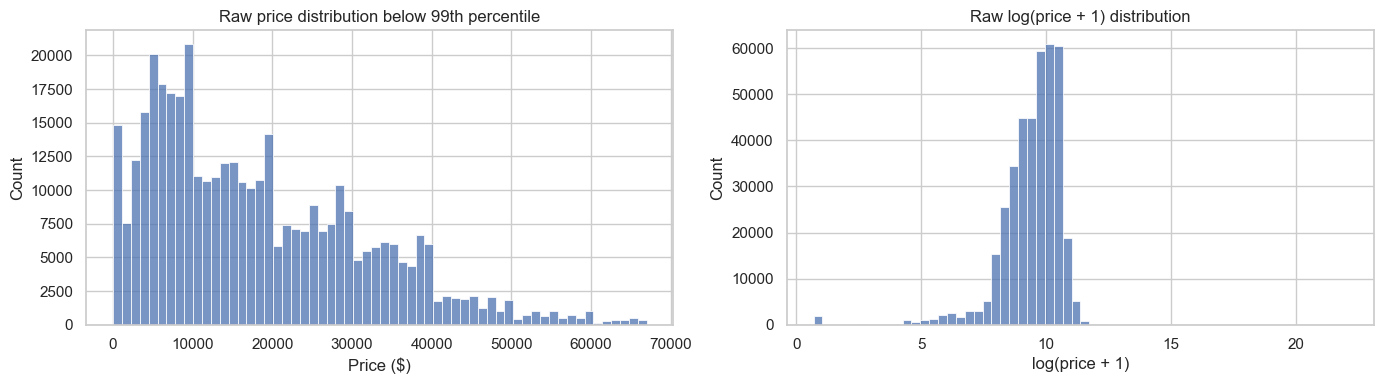

In [9]:
# Visualize the raw target distribution and log-transformed target to understand skew before modeling.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(raw.loc[raw["price"].between(1, raw["price"].quantile(0.99)), "price"], bins=60, ax=axes[0])
axes[0].set_title("Raw price distribution below 99th percentile")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log1p(raw.loc[raw["price"] > 0, "price"]), bins=60, ax=axes[1])
axes[1].set_title("Raw log(price + 1) distribution")
axes[1].set_xlabel("log(price + 1)")
plt.tight_layout()


## Data Preparation

The dataset is dirty enough that cleaning is a major part of the project. The rules below are explicit and reproducible:

- Remove placeholder or unrealistic prices.
- Remove extreme target outliers using a 95th-percentile cap selected from sensitivity testing, and remove odometer outliers using a high-percentile cutoff.
- Keep realistic vehicle years only.
- Drop identifier-like fields that do not generalize.
- Preserve missingness in important categorical fields by using `unknown` and missing-indicator features.
- Engineer vehicle age, mileage intensity, title risk, drivetrain, fuel, body type, luxury-brand, and cylinder features.
- Group rare categories before one-hot encoding to reduce overfitting and runtime, while retaining enough detail from `model_simplified` and `region` to capture meaningful market differences.

In [10]:
# Define reusable cleaning and feature-engineering functions so the workflow is reproducible.
def clean_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize text columns before category cleanup."""
    df = df.copy()
    obj_cols = df.select_dtypes(include="object").columns
    for col in obj_cols:
        df[col] = (
            df[col]
            .astype("string")
            .str.lower()
            .str.strip()
            .replace({"": pd.NA, "nan": pd.NA, "none": pd.NA})
        )
    return df


def clean_and_engineer(df: pd.DataFrame, price_cap_quantile: float = 0.99, top_model_count: int = 2000) -> pd.DataFrame:
    """Apply assignment-specific cleaning and feature engineering."""
    df = clean_text_columns(df)
    df = df.copy()

    # Preserve missingness as a signal for listing quality/completeness.
    for col in ["condition", "cylinders", "drive", "type", "paint_color", "size"]:
        if col in df.columns:
            df[f"{col}_missing"] = df[col].isna().astype(int)

    # Remove clearly invalid or unhelpful target values, then trim extreme outliers.
    df = df[df["price"] > 500]
    price_hi = df["price"].quantile(price_cap_quantile)
    df = df[df["price"] <= price_hi]

    # Clean key numeric fields.
    df = df[df["year"].between(1980, CURRENT_YEAR)]
    odo_hi = df["odometer"].quantile(0.99)
    df = df[df["odometer"].between(1, odo_hi)]

    df["year"] = df["year"].astype(int)
    df["vehicle_age"] = (CURRENT_YEAR - df["year"]).clip(lower=0)
    df["odometer_log"] = np.log1p(df["odometer"])
    df["miles_per_year"] = df["odometer"] / np.maximum(df["vehicle_age"], 1)
    df["miles_per_year"] = df["miles_per_year"].clip(upper=df["miles_per_year"].quantile(0.99))

    df["age_bucket"] = pd.cut(
        df["vehicle_age"],
        bins=[-1, 3, 7, 12, 20, np.inf],
        labels=["newer_0_3", "recent_4_7", "mid_age_8_12", "older_13_20", "classic_21_plus"],
    ).astype("string")
    df["mileage_bucket"] = pd.cut(
        df["odometer"],
        bins=[0, 30000, 75000, 125000, 200000, np.inf],
        labels=["very_low", "low", "medium", "high", "very_high"],
    ).astype("string")

    # Business-oriented indicator features.
    title = df["title_status"].fillna("unknown")
    df["has_clean_title"] = title.eq("clean").astype(int)
    df["has_title_issue"] = (~title.isin(["clean", "unknown"])).astype(int)
    df["is_4wd_or_awd"] = df["drive"].fillna("unknown").isin(["4wd", "awd"]).astype(int)
    df["is_electric_or_hybrid"] = df["fuel"].fillna("unknown").isin(["electric", "hybrid"]).astype(int)
    df["is_truck_or_pickup"] = df["type"].fillna("unknown").isin(["truck", "pickup"]).astype(int)
    df["is_suv_or_truck"] = df["type"].fillna("unknown").isin(["suv", "truck", "pickup"]).astype(int)
    df["is_manual"] = df["transmission"].fillna("unknown").eq("manual").astype(int)
    df["is_diesel"] = df["fuel"].fillna("unknown").eq("diesel").astype(int)

    luxury_brands = {
        "acura", "audi", "bmw", "cadillac", "infiniti", "jaguar", "lexus",
        "lincoln", "mercedes-benz", "porsche", "tesla", "volvo", "rover",
    }
    df["is_luxury_brand"] = df["manufacturer"].isin(luxury_brands).astype(int)

    # Extract cylinder count where possible. Electric/other listings remain missing/unknown.
    df["cylinders_num"] = df["cylinders"].str.extract(r"(\d+)").astype(float)

    condition_rank = {
        "salvage": 0,
        "fair": 1,
        "good": 2,
        "excellent": 3,
        "like new": 4,
        "new": 5,
    }
    df["condition_rank"] = df["condition"].map(condition_rank)

    # Explicit interactions help the linear model capture business-relevant nonlinear patterns.
    df["age_x_odometer_log"] = df["vehicle_age"] * df["odometer_log"]
    df["luxury_x_age"] = df["is_luxury_brand"] * df["vehicle_age"]
    df["truck_x_4wd"] = df["is_truck_or_pickup"] * df["is_4wd_or_awd"]

    # Simplify high-cardinality model by keeping common models only.
    model_counts = df["model"].value_counts(dropna=True)
    top_models = set(model_counts.head(top_model_count).index)
    df["model_simplified"] = np.where(df["model"].isin(top_models), df["model"], "other")
    df["make_model"] = (
        df["manufacturer"].fillna("unknown").astype("string")
        + "_"
        + pd.Series(df["model_simplified"], index=df.index).astype("string")
    )

    # Fill categorical missing values after derived features are created.
    for col in df.select_dtypes(include=["object", "string", "category"]).columns:
        df[col] = df[col].astype("string").fillna("unknown")

    # Drop fields that are identifiers, too granular, redundant, or not stable enough for a general model.
    df = df.drop(columns=["id", "VIN", "model", "year"], errors="ignore")

    return df


def group_rare_categories(df: pd.DataFrame, min_count: int = 250) -> pd.DataFrame:
    """Collapse sparse categories to reduce noisy one-hot features."""
    df = df.copy()
    cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
    for col in cat_cols:
        counts = df[col].value_counts(dropna=False)
        keep = counts[counts >= min_count].index
        df[col] = np.where(df[col].isin(keep), df[col], "other")
        df[col] = pd.Series(df[col], index=df.index, dtype="string")
    return df


In [11]:
# Apply the production cleaning rules and show how much data remains for analysis.
clean = clean_and_engineer(raw, price_cap_quantile=0.95, top_model_count=2000)
clean = group_rare_categories(clean, min_count=50)

print(f"Rows before cleaning: {raw.shape[0]:,}")
print(f"Rows after cleaning:  {clean.shape[0]:,}")
print(f"Rows removed:         {raw.shape[0] - clean.shape[0]:,}")
print(f"Columns after feature engineering: {clean.shape[1]:,}")
clean.head()


Rows before cleaning: 426,880
Rows after cleaning:  350,161
Rows removed:         76,719
Columns after feature engineering: 41


,region,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,condition_missing,cylinders_missing,drive_missing,type_missing,paint_color_missing,size_missing,vehicle_age,odometer_log,miles_per_year,age_bucket,mileage_bucket,has_clean_title,has_title_issue,is_4wd_or_awd,is_electric_or_hybrid,is_truck_or_pickup,is_suv_or_truck,is_manual,is_diesel,is_luxury_brand,cylinders_num,condition_rank,age_x_odometer_log,luxury_x_age,truck_x_4wd,model_simplified,make_model
27,auburn,33590,gmc,good,8 cylinders,gas,"57,923.00",clean,other,unknown,unknown,pickup,white,al,0,0,1,0,0,1,12,10.97,"4,826.92",mid_age_8_12,low,1,0,0,0,1,1,0,0,0,8.00,2.00,131.60,0,0,sierra 1500 crew cab slt,gmc_sierra 1500 crew cab slt
28,auburn,22590,chevrolet,good,8 cylinders,gas,"71,229.00",clean,other,unknown,unknown,pickup,blue,al,0,0,1,0,0,1,16,11.17,"4,451.81",older_13_20,low,1,0,0,0,1,1,0,0,0,8.00,2.00,178.78,0,0,silverado 1500,chevrolet_silverado 1500
29,auburn,39590,chevrolet,good,8 cylinders,gas,"19,160.00",clean,other,unknown,unknown,pickup,red,al,0,0,1,0,0,1,6,9.86,"3,193.33",recent_4_7,very_low,1,0,0,0,1,1,0,0,0,8.00,2.00,59.16,0,0,silverado 1500 crew,chevrolet_silverado 1500 crew
30,auburn,30990,toyota,good,8 cylinders,gas,"41,124.00",clean,other,unknown,unknown,pickup,red,al,0,0,1,0,0,1,9,10.62,"4,569.33",mid_age_8_12,low,1,0,0,0,1,1,0,0,0,8.00,2.00,95.62,0,0,tundra double cab sr,toyota_tundra double cab sr
31,auburn,15000,ford,excellent,6 cylinders,gas,"128,000.00",clean,automatic,rwd,full-size,truck,black,al,0,0,0,0,0,0,13,11.76,"9,846.15",older_13_20,high,1,0,0,0,1,1,0,0,0,6.00,3.00,152.88,0,0,f-150 xlt,ford_f-150 xlt


In [12]:
# Confirm cleaned numeric ranges after outlier handling and feature engineering.
clean_summary = clean[["price", "odometer", "vehicle_age", "miles_per_year", "odometer_log", "cylinders_num", "condition_rank"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
clean_summary


,count,mean,std,min,1%,5%,50%,95%,99%,max
price,"350,161.00","17,356.56","11,444.60",501.00,"1,000.00","2,950.00","14,995.00","38,950.00","43,800.00","45,590.00"
odometer,"350,161.00","94,767.64","60,664.31",1.00,180.00,"9,313.00","91,512.00","200,542.00","245,000.00","276,000.00"
vehicle_age,"350,161.00",14.20,6.35,4.00,6.00,7.00,13.00,26.00,37.00,46.00
miles_per_year,"350,161.00","6,516.13","3,470.37",0.02,11.06,"1,121.26","6,438.60","12,517.95","16,102.36","16,102.36"
odometer_log,"350,161.00",11.07,1.31,0.69,5.20,9.14,11.42,12.21,12.41,12.53
cylinders_num,"207,368.00",5.88,1.57,3.00,4.00,4.00,6.00,8.00,8.00,12.00
condition_rank,"221,727.00",2.53,0.70,0.00,1.00,2.00,2.00,4.00,4.00,5.00


In [13]:
# Check remaining missing values after cleaning; numeric missingness will be handled inside model pipelines.
clean_missing = (
    clean.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)
clean_missing.head(15)


,missing_pct
cylinders_num,40.78
condition_rank,36.68
region,0.00
is_suv_or_truck,0.00
age_bucket,0.00
mileage_bucket,0.00
has_clean_title,0.00
has_title_issue,0.00
is_4wd_or_awd,0.00
is_electric_or_hybrid,0.00


## Exploratory Data Analysis

The plots use medians where possible because used-car prices are right-skewed. This avoids letting a small number of very expensive vehicles dominate the business story.

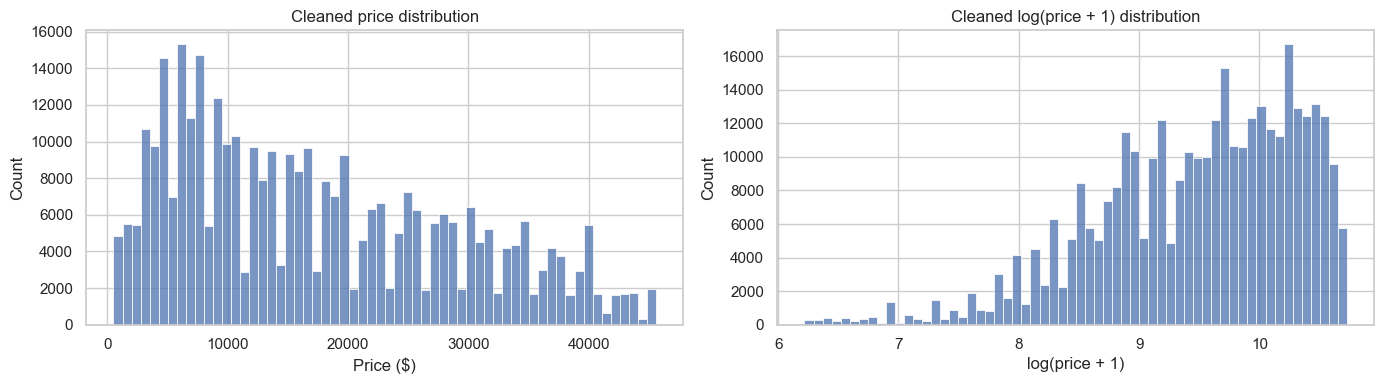

In [14]:
# Compare the cleaned price distribution on raw and log scales.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(clean["price"], bins=60, ax=axes[0])
axes[0].set_title("Cleaned price distribution")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log1p(clean["price"]), bins=60, ax=axes[1])
axes[1].set_title("Cleaned log(price + 1) distribution")
axes[1].set_xlabel("log(price + 1)")
plt.tight_layout()


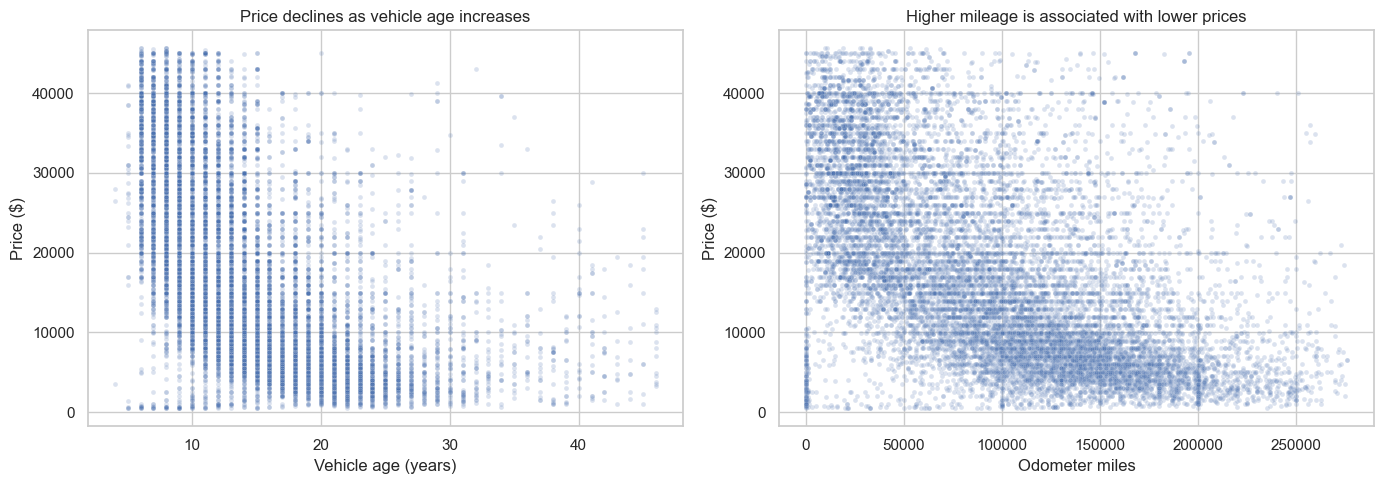

In [15]:
# Use sampled scatterplots to show the relationship between price, vehicle age, and mileage without overplotting all rows.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=clean.sample(min(15000, len(clean)), random_state=RANDOM_STATE), x="vehicle_age", y="price", alpha=0.2, s=12, ax=axes[0])
axes[0].set_title("Price declines as vehicle age increases")
axes[0].set_xlabel("Vehicle age (years)")
axes[0].set_ylabel("Price ($)")

sns.scatterplot(data=clean.sample(min(15000, len(clean)), random_state=RANDOM_STATE + 1), x="odometer", y="price", alpha=0.2, s=12, ax=axes[1])
axes[1].set_title("Higher mileage is associated with lower prices")
axes[1].set_xlabel("Odometer miles")
axes[1].set_ylabel("Price ($)")
plt.tight_layout()


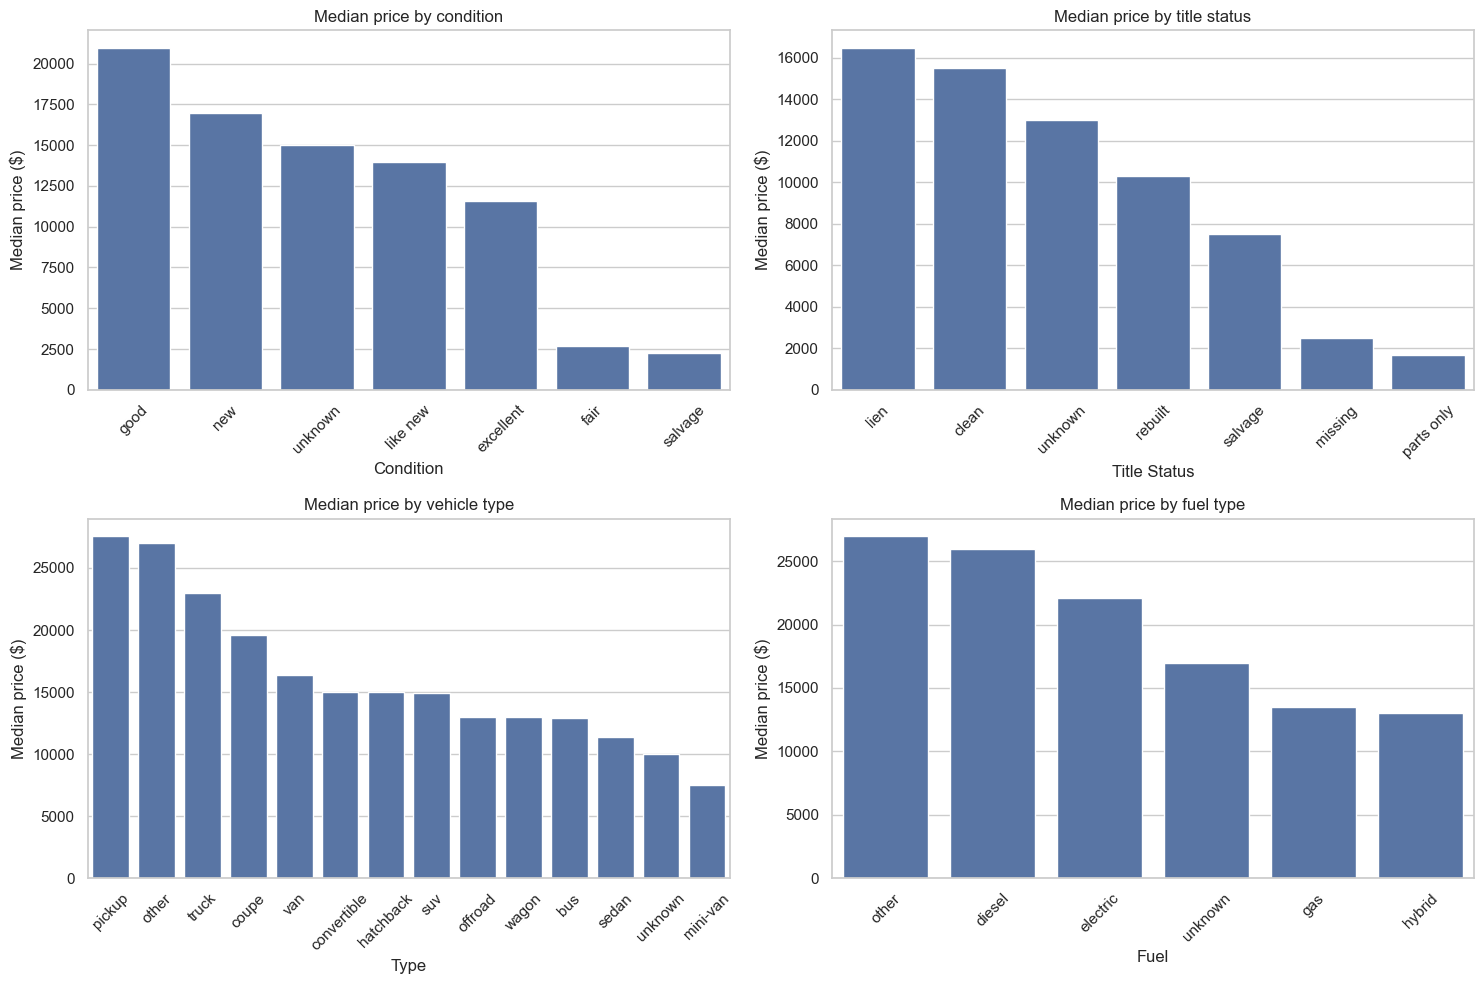

In [16]:
# Compare median prices across important categorical fields; medians are robust to skewed prices.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_specs = [
    ("condition", "Median price by condition"),
    ("title_status", "Median price by title status"),
    ("type", "Median price by vehicle type"),
    ("fuel", "Median price by fuel type"),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    order = clean.groupby(col)["price"].median().sort_values(ascending=False).index
    sns.barplot(data=clean, x=col, y="price", estimator=np.median, order=order, errorbar=None, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Median price ($)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()


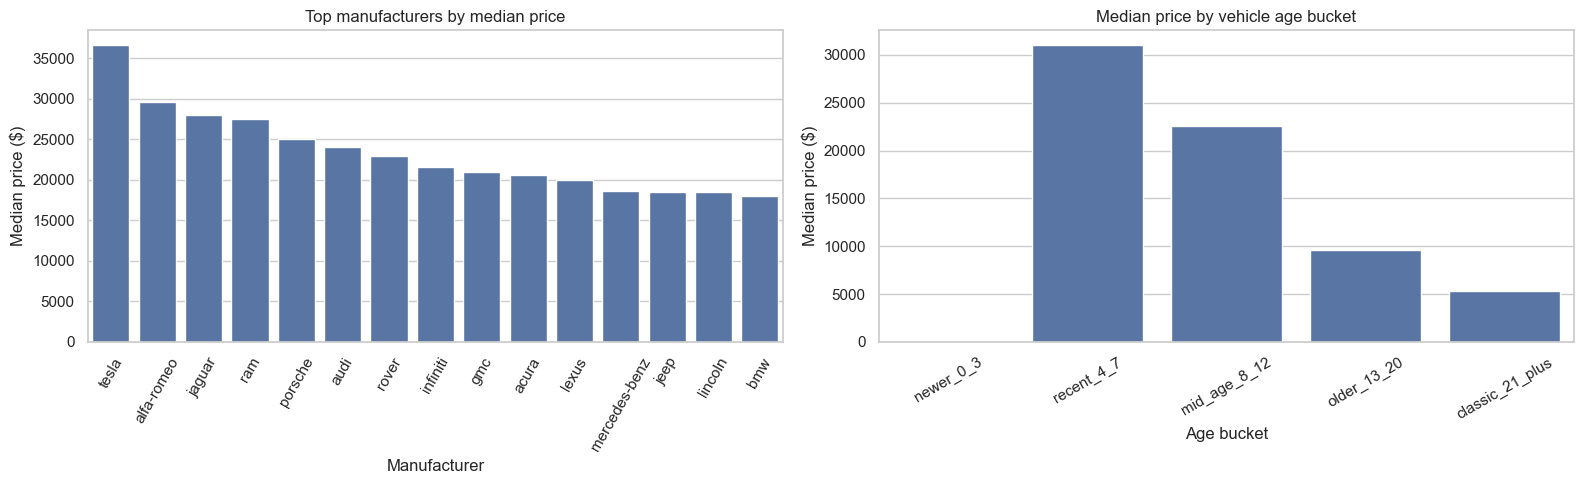

In [17]:
# Identify manufacturers and vehicle-age buckets associated with higher median prices.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_mfr = clean.groupby("manufacturer")["price"].median().sort_values(ascending=False).head(15).index
sns.barplot(data=clean[clean["manufacturer"].isin(top_mfr)], x="manufacturer", y="price", estimator=np.median, order=top_mfr, errorbar=None, ax=axes[0])
axes[0].set_title("Top manufacturers by median price")
axes[0].set_xlabel("Manufacturer")
axes[0].set_ylabel("Median price ($)")
axes[0].tick_params(axis="x", rotation=60)

age_order = ["newer_0_3", "recent_4_7", "mid_age_8_12", "older_13_20", "classic_21_plus"]
sns.barplot(data=clean, x="age_bucket", y="price", estimator=np.median, order=age_order, errorbar=None, ax=axes[1])
axes[1].set_title("Median price by vehicle age bucket")
axes[1].set_xlabel("Age bucket")
axes[1].set_ylabel("Median price ($)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()


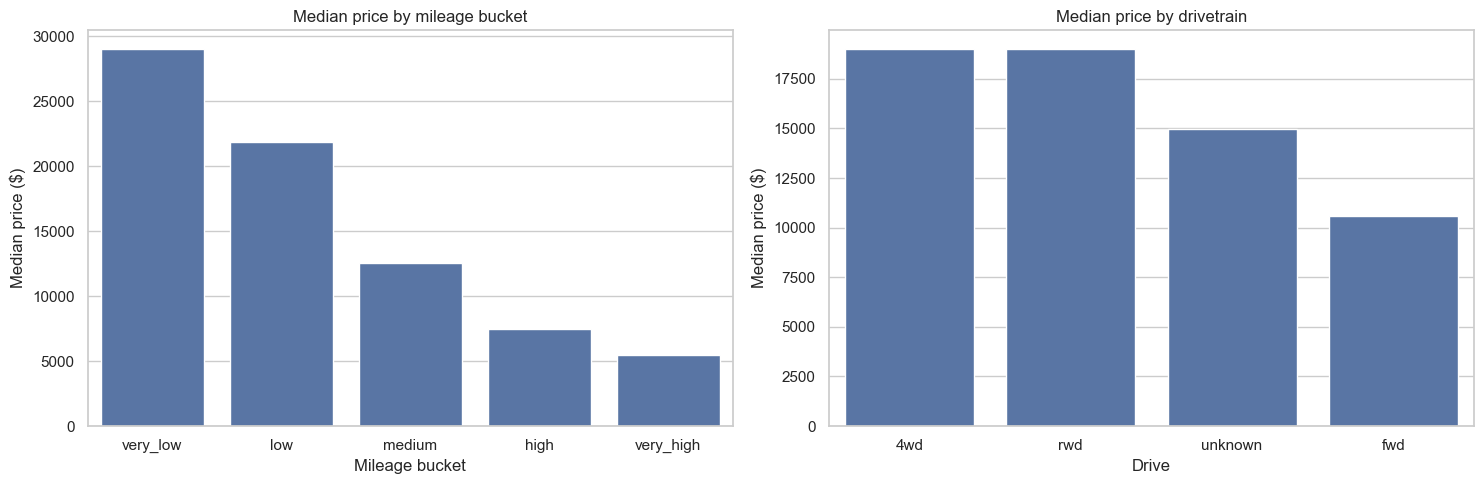

In [18]:
# Compare median prices by mileage bucket and drivetrain.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mileage_order = ["very_low", "low", "medium", "high", "very_high"]
sns.barplot(data=clean, x="mileage_bucket", y="price", estimator=np.median, order=mileage_order, errorbar=None, ax=axes[0])
axes[0].set_title("Median price by mileage bucket")
axes[0].set_xlabel("Mileage bucket")
axes[0].set_ylabel("Median price ($)")

drive_order = clean.groupby("drive")["price"].median().sort_values(ascending=False).index
sns.barplot(data=clean, x="drive", y="price", estimator=np.median, order=drive_order, errorbar=None, ax=axes[1])
axes[1].set_title("Median price by drivetrain")
axes[1].set_xlabel("Drive")
axes[1].set_ylabel("Median price ($)")
plt.tight_layout()


## Modeling

The modeling stage compares a simple baseline against several regression pipelines. Numeric features are scaled, optionally expanded to degree-2 polynomial terms, and scaled again while categorical features remain one-hot encoded; this captures nonlinear age and mileage effects without creating meaningless powers of one-hot indicators. The unregularized Linear Regression comparison uses non-polynomial numeric features for numerical stability. The final feature set keeps richer model, make-model, and regional information because experiments showed these categories materially improve holdout performance. A boosted-tree challenger is also tested as a less-interpretable performance benchmark. To keep runtime reasonable with more than 400,000 raw rows and many categorical variables, cross-validation is performed on a reproducible modeling sample. The final train/test split still gives an honest holdout estimate.

The primary metric is **MAE** because it translates directly into average dollar error. RMSE and R² are included as supporting metrics.

In [19]:
# Split the cleaned data into predictors and target, then create a reproducible modeling sample for tractable cross-validation.
target = "price"
X = clean.drop(columns=[target])
y = clean[target]

# Use a reproducible sample for faster cross-validation and grid search.
model_n = min(MODEL_SAMPLE_N, len(clean))
model_idx = clean.sample(model_n, random_state=RANDOM_STATE).index
X_model = X.loc[model_idx].copy()
y_model = y.loc[model_idx].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(f"Modeling rows: {len(X_model):,}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Categorical features:", categorical_features)


Modeling rows: 200,000
Numeric features: 24
Categorical features: 16
Categorical features: ['region', 'manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'age_bucket', 'mileage_bucket', 'model_simplified', 'make_model']


In [20]:
# Build preprocessing pipelines for linear models: numeric imputation/scaling/polynomial terms and categorical one-hot encoding.
numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("pre_poly_scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("post_poly_scaler", StandardScaler(with_mean=False)),
    ]
)

numeric_preprocess_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess_linear, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

def regression_report(model, X_train, y_train, X_test, y_test, cv=3):
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    }
    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        "cv_mae": -cv_scores["test_mae"].mean(),
        "cv_rmse": -cv_scores["test_rmse"].mean(),
        "cv_r2": cv_scores["test_r2"].mean(),
        "test_mae": mean_absolute_error(y_test, preds),
        "test_rmse": mean_squared_error(y_test, preds) ** 0.5,
        "test_r2": r2_score(y_test, preds),
    }


### Price Cap Sensitivity

Because the data has extreme and suspicious price values, this quick sensitivity check compares several upper-price caps on a smaller sample. The selected production cleaning uses the 95th-percentile cap because it removes the noisiest high-price listings and scopes the analysis to ordinary dealership inventory rather than exotic, collector, or likely erroneous listings. This scope is important when interpreting the final recommendations.

In [21]:
# Test several price outlier caps to justify the final business scope and cleaning threshold.
def quick_ridge_score(df: pd.DataFrame, sample_n: int = 60_000) -> dict[str, float]:
    Xq = df.drop(columns=[target])
    yq = df[target]
    idx = df.sample(min(sample_n, len(df)), random_state=RANDOM_STATE).index
    Xq = Xq.loc[idx]
    yq = yq.loc[idx]
    Xq_train, Xq_test, yq_train, yq_test = train_test_split(
        Xq, yq, test_size=0.2, random_state=RANDOM_STATE
    )
    num_q = Xq_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_q = Xq_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    pre_q = ColumnTransformer(
        transformers=[
            ("num", numeric_preprocess, num_q),
            ("cat", categorical_preprocess, cat_q),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )
    model_q = Pipeline([("preprocess", pre_q), ("model", Ridge(alpha=10.0))])
    model_q.fit(Xq_train, yq_train)
    pred_q = model_q.predict(Xq_test)
    return {
        "rows": len(df),
        "test_mae": mean_absolute_error(yq_test, pred_q),
        "test_rmse": mean_squared_error(yq_test, pred_q) ** 0.5,
        "test_r2": r2_score(yq_test, pred_q),
    }

cap_results = []
for cap in [0.95, 0.98, 0.99]:
    cap_df = group_rare_categories(
        clean_and_engineer(raw, price_cap_quantile=cap, top_model_count=2000),
        min_count=50,
    )
    metrics = quick_ridge_score(cap_df)
    metrics["price_cap_quantile"] = cap
    cap_results.append(metrics)

cap_results_df = (
    pd.DataFrame(cap_results)
    .set_index("price_cap_quantile")
    .sort_values("test_mae")
)
cap_results_df

,rows,test_mae,test_rmse,test_r2
price_cap_quantile,,,,
0.95,350161,"3,247.60","4,862.87",0.82
0.98,360969,"3,553.58","5,517.55",0.81
0.99,364598,"3,679.11","5,814.86",0.81


In [22]:
# Evaluate baseline and linear-family models using cross-validation plus a holdout test set.
models = {
    "Median baseline": DummyRegressor(strategy="median"),
    "Linear regression": Pipeline([("preprocess", preprocessor_linear), ("model", LinearRegression())]),
    "Ridge regression": Pipeline([("preprocess", preprocessor), ("model", Ridge(alpha=10.0))]),
    "Log-price Ridge": TransformedTargetRegressor(
        regressor=Pipeline([("preprocess", preprocessor), ("model", Ridge(alpha=10.0))]),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
}

results = []
for name, model in models.items():
    print(f"Evaluating {name}...")
    metrics = regression_report(model, X_train, y_train, X_test, y_test, cv=3)
    metrics["model"] = name
    results.append(metrics)

results_df = (
    pd.DataFrame(results)
    .set_index("model")
    .sort_values("test_mae")
)
results_df


Evaluating Median baseline...


Evaluating Linear regression...


Evaluating Ridge regression...


Evaluating Log-price Ridge...


,cv_mae,cv_rmse,cv_r2,test_mae,test_rmse,test_r2
model,,,,,,
Ridge regression,"3,175.48","4,832.74",0.82,"3,152.80","4,817.89",0.82
Log-price Ridge,"3,399.34","5,287.37",0.79,"3,380.46","5,283.04",0.79
Linear regression,"3,560.80","5,275.72",0.79,"3,554.13","5,274.11",0.79
Median baseline,"9,536.56","11,663.47",-0.04,"9,568.71","11,685.83",-0.04


In [23]:
# Tune Ridge and log-price Ridge with a small grid over regularization strength and numeric polynomial degree.
ridge_grid_start = time.perf_counter()

# Small grid search for Ridge regularization. This satisfies the assignment requirement
# without launching an expensive exhaustive search on the full dataset.
ridge_pipe = Pipeline([("preprocess", preprocessor), ("model", Ridge())])
ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid={
        "preprocess__num__poly__degree": [1, 2],
        "model__alpha": [10.0, 50.0, 100.0, 500.0],
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,
)
ridge_grid.fit(X_train, y_train)

log_ridge_grid = GridSearchCV(
    TransformedTargetRegressor(
        regressor=Pipeline([("preprocess", preprocessor), ("model", Ridge())]),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
    param_grid={
        "regressor__preprocess__num__poly__degree": [1, 2],
        "regressor__model__alpha": [10.0, 50.0, 100.0, 500.0],
    },
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,
)
log_ridge_grid.fit(X_train, y_train)

print("Best raw Ridge alpha:", ridge_grid.best_params_)
print("Best raw Ridge CV MAE:", -ridge_grid.best_score_)
print("Best log Ridge alpha:", log_ridge_grid.best_params_)
print("Best log Ridge CV MAE:", -log_ridge_grid.best_score_)
record_timing("Ridge and log-Ridge grid search", ridge_grid_start)


Best raw Ridge alpha: {'model__alpha': 10.0, 'preprocess__num__poly__degree': 2}
Best raw Ridge CV MAE: 3175.4781269814252
Best log Ridge alpha: {'regressor__model__alpha': 10.0, 'regressor__preprocess__num__poly__degree': 2}
Best log Ridge CV MAE: 3399.3414852150613
Ridge and log-Ridge grid search completed in 414.3 seconds


In [24]:
# Re-evaluate the tuned Ridge models so their CV and test metrics appear in the final comparison table.
tuned_models = {
    "Tuned Ridge": ridge_grid.best_estimator_,
    "Tuned Log Ridge": log_ridge_grid.best_estimator_,
}

tuned_results = []
for name, model in tuned_models.items():
    print(f"Evaluating {name}...")
    metrics = regression_report(model, X_train, y_train, X_test, y_test, cv=3)
    metrics["model"] = name
    tuned_results.append(metrics)

final_results = (
    pd.concat([results_df.reset_index(), pd.DataFrame(tuned_results)], ignore_index=True)
    .drop_duplicates(subset="model", keep="last")
    .set_index("model")
    .sort_values("test_mae")
)
final_results


Evaluating Tuned Ridge...


Evaluating Tuned Log Ridge...


,cv_mae,cv_rmse,cv_r2,test_mae,test_rmse,test_r2
model,,,,,,
Ridge regression,"3,175.48","4,832.74",0.82,"3,152.80","4,817.89",0.82
Tuned Ridge,"3,175.48","4,832.74",0.82,"3,152.80","4,817.89",0.82
Log-price Ridge,"3,399.34","5,287.37",0.79,"3,380.46","5,283.04",0.79
Tuned Log Ridge,"3,399.34","5,287.37",0.79,"3,380.46","5,283.04",0.79
Linear regression,"3,560.80","5,275.72",0.79,"3,554.13","5,274.11",0.79
Median baseline,"9,536.56","11,663.47",-0.04,"9,568.71","11,685.83",-0.04


### Cohort-Inspired Hard-Cap Experiment

A cohort discussion suggested that stronger model-string cleaning, hard business-readable caps, and focusing on ordinary consumer vehicle types can improve model quality. This experiment tests that idea separately from the main workflow. It keeps only cars, pickups, trucks, SUVs, hatchbacks, wagons, coupes, convertibles, vans, and mini-vans; applies hard caps to year, odometer, and price; cleans model strings by removing common trim/engine/seller noise; and benchmarks a compact log-price Ridge model against a boosted-tree model.

In [ ]:
# Test a cohort-inspired cleaning strategy: hard caps, ordinary vehicle types, and cleaner model labels.
import re

def clean_model_label(value):
    if pd.isna(value):
        return "unknown"
    text = str(value).lower().strip()
    text = re.sub(r"\b(19|20)\d{2}\b", " ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    noise_words = {
        "automatic", "auto", "manual", "awd", "4wd", "fwd", "rwd", "diesel",
        "gas", "gasoline", "hybrid", "electric", "turbo", "clean", "title",
        "excellent", "good", "fair", "new", "used", "limited", "premium",
        "sport", "base", "crew", "cab", "sedan", "coupe", "hatchback",
        "wagon", "convertible", "pickup", "truck", "suv", "van", "mini",
        "door", "doors", "owner", "miles", "mile", "low", "loaded", "leather",
        "navigation", "backup", "camera", "sale", "price", "obo", "must", "see",
    }
    tokens = [tok for tok in text.split() if tok not in noise_words and not tok.isdigit()]
    cleaned = " ".join(tokens[:4]).strip()
    return cleaned if cleaned else "unknown"


def clean_and_engineer_hard_cap(df, top_model_count=2000):
    df = clean_text_columns(df).copy()
    ordinary_types = {
        "sedan", "coupe", "hatchback", "wagon", "convertible", "suv",
        "pickup", "truck", "van", "mini-van", "other",
    }
    df = df[df["type"].fillna("unknown").isin(ordinary_types)]
    df = df[df["price"].between(1_000, 250_000)]
    df = df[df["year"].between(1995, CURRENT_YEAR)]
    df = df[df["odometer"].between(1_000, 250_000)]

    for col in ["condition", "cylinders", "drive", "type", "paint_color", "size"]:
        if col in df.columns:
            df[f"{col}_missing"] = df[col].isna().astype(int)

    df["year"] = df["year"].astype(int)
    df["vehicle_age"] = (CURRENT_YEAR - df["year"]).clip(lower=0)
    df["odometer_log"] = np.log1p(df["odometer"])
    df["miles_per_year"] = df["odometer"] / np.maximum(df["vehicle_age"], 1)
    df["model_clean"] = df["model"].map(clean_model_label).astype("string")

    title = df["title_status"].fillna("unknown")
    df["has_clean_title"] = title.eq("clean").astype(int)
    df["has_title_issue"] = (~title.isin(["clean", "unknown"])).astype(int)
    df["is_4wd_or_awd"] = df["drive"].fillna("unknown").isin(["4wd", "awd"]).astype(int)
    df["is_manual"] = df["transmission"].fillna("unknown").eq("manual").astype(int)
    df["is_diesel"] = df["fuel"].fillna("unknown").eq("diesel").astype(int)
    df["is_suv_or_truck"] = df["type"].fillna("unknown").isin(["suv", "truck", "pickup"]).astype(int)

    luxury_brands = {
        "acura", "audi", "bmw", "cadillac", "infiniti", "jaguar", "lexus",
        "lincoln", "mercedes-benz", "porsche", "tesla", "volvo", "rover",
    }
    df["is_luxury_brand"] = df["manufacturer"].isin(luxury_brands).astype(int)
    df["age_x_odometer_log"] = df["vehicle_age"] * df["odometer_log"]

    top_models = set(df["model_clean"].value_counts(dropna=True).head(top_model_count).index)
    df["model_clean"] = np.where(df["model_clean"].isin(top_models), df["model_clean"], "other")
    df["make_model_clean"] = df["manufacturer"].fillna("unknown").astype("string") + "_" + pd.Series(df["model_clean"], index=df.index).astype("string")

    for col in df.select_dtypes(include=["object", "string", "category"]).columns:
        df[col] = df[col].astype("string").fillna("unknown")
    df = df.drop(columns=["id", "VIN", "model", "year", "size"], errors="ignore")
    return group_rare_categories(df, min_count=50)


def cohort_experiment_score(df, sample_n=120_000):
    X_exp = df.drop(columns=["price"])
    y_exp = df["price"]
    idx = df.sample(min(sample_n, len(df)), random_state=RANDOM_STATE).index
    X_exp = X_exp.loc[idx]
    y_exp = y_exp.loc[idx]
    X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
        X_exp, y_exp, test_size=0.2, random_state=RANDOM_STATE
    )

    compact_cols = ["vehicle_age", "odometer", "manufacturer", "model_clean"]
    compact_X_train = X_exp_train[compact_cols]
    compact_X_test = X_exp_test[compact_cols]
    compact_num = ["vehicle_age", "odometer"]
    compact_cat = ["manufacturer", "model_clean"]
    compact_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                        ("selector", SelectKBest(score_func=f_regression, k=3)),
                        ("post_scaler", StandardScaler(with_mean=False)),
                    ]
                ),
                compact_num,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
                    ]
                ),
                compact_cat,
            ),
        ],
        sparse_threshold=0.3,
    )
    compact_ridge = TransformedTargetRegressor(
        regressor=Pipeline([("preprocess", compact_preprocessor), ("model", Ridge(alpha=1.0))]),
        func=np.log1p,
        inverse_func=np.expm1,
    )
    compact_ridge.fit(compact_X_train, y_exp_train)
    compact_preds = compact_ridge.predict(compact_X_test)

    num_cols = X_exp_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_cols = X_exp_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    tree_pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
                        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1)),
                    ]
                ),
                cat_cols,
            ),
        ]
    )
    tree_model = Pipeline(
        steps=[
            ("preprocess", tree_pre),
            ("model", HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_leaf_nodes=31, l2_regularization=0.1, random_state=RANDOM_STATE)),
        ]
    )
    tree_model.fit(X_exp_train, y_exp_train)
    tree_preds = tree_model.predict(X_exp_test)

    rows = []
    for name, preds in [("Compact log-price Ridge", compact_preds), ("Hard-cap boosted tree", tree_preds)]:
        rows.append(
            {
                "model": name,
                "rows_after_cleaning": len(df),
                "test_mae": mean_absolute_error(y_exp_test, preds),
                "test_rmse": mean_squared_error(y_exp_test, preds) ** 0.5,
                "test_r2": r2_score(y_exp_test, preds),
            }
        )
    return pd.DataFrame(rows).set_index("model").sort_values("test_mae")

cohort_clean = clean_and_engineer_hard_cap(raw, top_model_count=2000)
cohort_experiment_results = cohort_experiment_score(cohort_clean)
cohort_experiment_results

                         rows_after_cleaning  test_mae  test_rmse  test_r2
model                                                                     
Hard-cap boosted tree                 279370  3,202.31   5,190.69     0.87
Compact log-price Ridge               279370  4,171.57   7,848.30     0.71

### Boosted Tree Challenger

A histogram gradient boosting model is included as a performance-oriented challenger. It uses ordinal-encoded categorical variables, so it is less directly interpretable than Ridge, but it can capture nonlinear relationships and interactions automatically. Cross-validation is included so the best-performing model is evaluated using the same rigor as the linear models.

In [25]:
# Train and cross-validate a boosted-tree challenger that can capture nonlinear patterns automatically.
boosted_start = time.perf_counter()

tree_numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

tree_categorical_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ),
        ),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_preprocess, numeric_features),
        ("cat", tree_categorical_preprocess, categorical_features),
    ],
    remainder="drop",
)

boosted_tree = Pipeline(
    steps=[
        ("preprocess", tree_preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=250,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=0.1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

boosted_cv_scores = cross_validate(
    boosted_tree,
    X_train,
    y_train,
    cv=3,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    n_jobs=1,
)

boosted_tree.fit(X_train, y_train)
boosted_preds = boosted_tree.predict(X_test)
boosted_result = pd.Series(
    {
        "cv_mae": -boosted_cv_scores["test_mae"].mean(),
        "cv_rmse": -boosted_cv_scores["test_rmse"].mean(),
        "cv_r2": boosted_cv_scores["test_r2"].mean(),
        "test_mae": mean_absolute_error(y_test, boosted_preds),
        "test_rmse": mean_squared_error(y_test, boosted_preds) ** 0.5,
        "test_r2": r2_score(y_test, boosted_preds),
    },
    name="HistGradientBoosting challenger",
)
record_timing("Boosted-tree CV and training", boosted_start)
boosted_result

Boosted-tree CV and training completed in 24.7 seconds


cv_mae      2,993.08
cv_rmse     4,497.34
cv_r2           0.85
test_mae    2,983.47
test_rmse   4,493.08
test_r2         0.85
Name: HistGradientBoosting challenger, dtype: float64

In [26]:
# Combine all model results into one table sorted by holdout MAE.
final_results_with_challenger = pd.concat(
    [
        final_results,
        boosted_result.to_frame().T.reindex(columns=final_results.columns),
    ]
).sort_values("test_mae")
final_results_with_challenger

,cv_mae,cv_rmse,cv_r2,test_mae,test_rmse,test_r2
HistGradientBoosting challenger,"2,993.08","4,497.34",0.85,"2,983.47","4,493.08",0.85
Ridge regression,"3,175.48","4,832.74",0.82,"3,152.80","4,817.89",0.82
Tuned Ridge,"3,175.48","4,832.74",0.82,"3,152.80","4,817.89",0.82
Log-price Ridge,"3,399.34","5,287.37",0.79,"3,380.46","5,283.04",0.79
Tuned Log Ridge,"3,399.34","5,287.37",0.79,"3,380.46","5,283.04",0.79
Linear regression,"3,560.80","5,275.72",0.79,"3,554.13","5,274.11",0.79
Median baseline,"9,536.56","11,663.47",-0.04,"9,568.71","11,685.83",-0.04


### Robustness Check: Make-Model and Region

Because `make_model` and `region` are high-cardinality features, they could make model performance look stronger by capturing dataset-specific lookup patterns. This robustness check compares a boosted-tree model with all features against the same model after dropping `make_model` and `region`. If performance remains reasonable without them, the model is not relying only on those high-cardinality fields; if performance drops, that confirms they contain important market signal.

In [27]:
# Compare boosted-tree performance with and without high-cardinality make/model/location features.
def boosted_holdout_score(X_train_input, y_train_input, X_test_input, y_test_input, train_n=60_000, test_n=20_000):
    train_idx = X_train_input.sample(min(train_n, len(X_train_input)), random_state=RANDOM_STATE).index
    test_idx = X_test_input.sample(min(test_n, len(X_test_input)), random_state=RANDOM_STATE).index

    X_train_sample = X_train_input.loc[train_idx]
    y_train_sample = y_train_input.loc[train_idx]
    X_test_sample = X_test_input.loc[test_idx]
    y_test_sample = y_test_input.loc[test_idx]

    numeric_cols = X_train_sample.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = X_train_sample.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    robustness_preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                encoded_missing_value=-1,
                            ),
                        ),
                    ]
                ),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    robustness_model = Pipeline(
        steps=[
            ("preprocess", robustness_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=150,
                    learning_rate=0.08,
                    max_leaf_nodes=31,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    robustness_model.fit(X_train_sample, y_train_sample)
    preds = robustness_model.predict(X_test_sample)
    return {
        "features": X_train_sample.shape[1],
        "test_mae": mean_absolute_error(y_test_sample, preds),
        "test_rmse": mean_squared_error(y_test_sample, preds) ** 0.5,
        "test_r2": r2_score(y_test_sample, preds),
    }

robustness_start = time.perf_counter()
robustness_rows = []
feature_sets = {
    "All features": X_train.columns.tolist(),
    "Without make_model and region": [
        col for col in X_train.columns if col not in ["make_model", "region"]
    ],
}

for label, cols in feature_sets.items():
    metrics = boosted_holdout_score(
        X_train[cols], y_train, X_test[cols], y_test
    )
    metrics["feature_set"] = label
    robustness_rows.append(metrics)

robustness_df = (
    pd.DataFrame(robustness_rows)
    .set_index("feature_set")
    .sort_values("test_mae")
)
record_timing("Robustness check without make_model/region", robustness_start)
robustness_df

Robustness check without make_model/region completed in 9.9 seconds


,features,test_mae,test_rmse,test_r2
feature_set,,,,
All features,40,"3,183.87","4,770.95",0.83
Without make_model and region,38,"3,193.69","4,789.82",0.83


## Evaluation and Interpretation

The final model should be judged by whether it materially beats the median baseline, generalizes to holdout data, and produces insights that are usable by a dealership. The boosted tree is treated as the strongest predictive model, while Ridge is retained as the clearest interpretation model because its one-hot encoded coefficients and permutation importance are easier to connect to business recommendations.

In [28]:
# Select the model with the lowest holdout MAE while preserving the full comparison table for context.
best_name = final_results_with_challenger.index[0]
best_model = boosted_tree if best_name == "HistGradientBoosting challenger" else tuned_models.get(best_name, models.get(best_name))
print(f"Best model by test MAE: {best_name}")
print(final_results_with_challenger.loc[best_name])


Best model by test MAE: HistGradientBoosting challenger
cv_mae      2,993.08
cv_rmse     4,497.34
cv_r2           0.85
test_mae    2,983.47
test_rmse   4,493.08
test_r2         0.85
Name: HistGradientBoosting challenger, dtype: float64


In [29]:
# Inspect Ridge coefficients for directional clues, while remembering coefficients can be unstable with correlated polynomial features.
# Coefficient interpretation from the tuned raw Ridge model.
# Raw Ridge is easier to inspect than the boosted tree, but coefficient signs should be interpreted cautiously because polynomial terms, interactions, and correlated features can shift individual coefficient directions.
interpretable_model = ridge_grid.best_estimator_
feature_names = interpretable_model.named_steps["preprocess"].get_feature_names_out()
coefs = interpretable_model.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_positive = coef_df.sort_values("coefficient", ascending=False).head(20)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(20)

print("Top positive price associations")
display(top_positive[["feature", "coefficient"]])
print("Top negative price associations")
display(top_negative[["feature", "coefficient"]])


Top positive price associations


,feature,coefficient
8,num__odometer_log,"8,858.24"
189,num__odometer_log miles_per_year,"7,917.88"
957,cat__model_simplified_5500,"7,872.19"
745,cat__manufacturer_porsche,"7,868.72"
2119,cat__make_model_chevrolet_cc4500,"7,271.38"
1056,cat__model_simplified_cc4500,"7,271.38"
750,cat__manufacturer_tesla,"7,245.39"
2130,cat__make_model_chevrolet_corvette grand sport,"7,183.29"
1128,cat__model_simplified_corvette grand sport,"7,183.29"
2662,cat__make_model_lexus_lx 470,"6,467.83"


Top negative price associations


,feature,coefficient
0,num__odometer,"-8,804.37"
492,cat__region_klamath falls,"-7,042.89"
891,cat__model_simplified_1500 classic regular cab,"-5,731.34"
2854,cat__make_model_ram_1500 classic regular cab,"-5,731.34"
318,num__age_x_odometer_log^2,"-5,583.98"
2467,cat__make_model_harley-davidson_other,"-5,055.57"
1020,cat__model_simplified_blue bird blue bird,"-4,948.16"
2998,cat__make_model_unknown_blue bird blue bird,"-4,948.16"
725,cat__manufacturer_fiat,"-4,822.71"
1781,cat__model_simplified_spark,"-4,609.44"


In [30]:
# Use permutation importance on the Ridge model to identify which original feature groups matter most.
# Permutation importance on a small holdout sample gives a model-agnostic view.
# This is intentionally sampled to keep runtime reasonable.
importance_n = min(3000, len(X_test))
importance_X = X_test.sample(importance_n, random_state=RANDOM_STATE)
importance_y = y_test.loc[importance_X.index]

perm = permutation_importance(
    ridge_grid.best_estimator_,
    importance_X,
    importance_y,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
perm_df = (
    pd.DataFrame({"feature": X_test.columns, "importance_mae_increase": perm.importances_mean})
    .sort_values("importance_mae_increase", ascending=False)
)
perm_df.head(20)


,feature,importance_mae_increase
5,odometer,"7,588.51"
20,odometer_log,"4,360.02"
19,vehicle_age,"3,640.46"
21,miles_per_year,"3,208.40"
35,age_x_odometer_log,"2,795.26"
32,is_luxury_brand,"1,285.57"
1,manufacturer,808.53
38,model_simplified,576.74
39,make_model,575.15
36,luxury_x_age,527.53


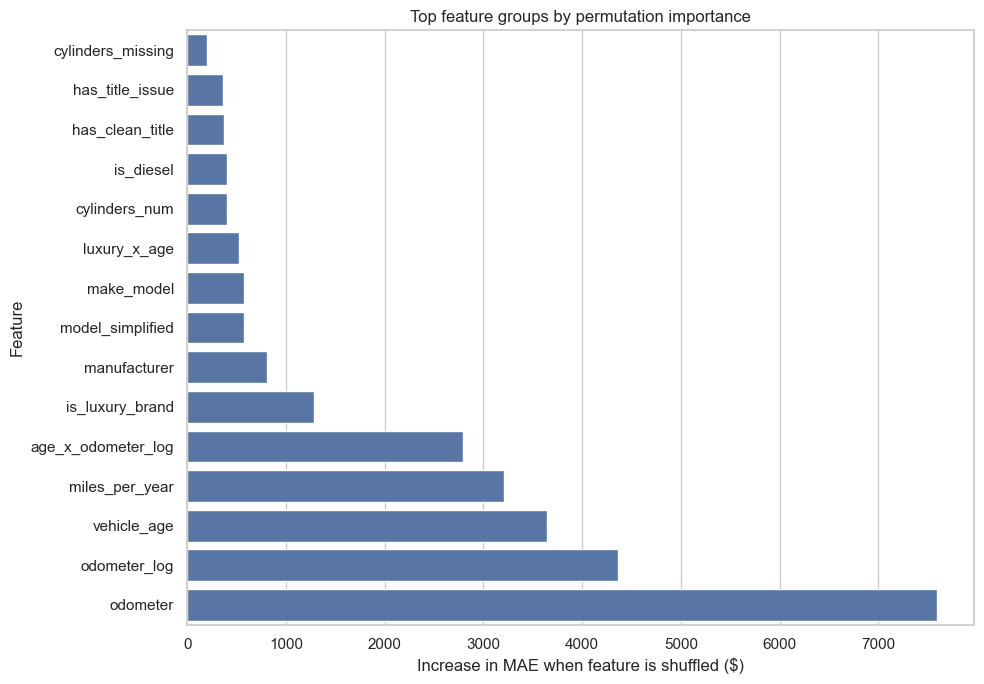

In [31]:
# Visualize the most important feature groups in business-friendly terms.
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = perm_df.head(15).sort_values("importance_mae_increase")
sns.barplot(data=plot_df, x="importance_mae_increase", y="feature", ax=ax)
ax.set_title("Top feature groups by permutation importance")
ax.set_xlabel("Increase in MAE when feature is shuffled ($)")
ax.set_ylabel("Feature")
plt.tight_layout()


## Runtime Summary

The following table records the runtime of the most expensive notebook steps. This helps future readers understand which cells take the longest to execute.

In [32]:
# Summarize the longest-running cells captured during model comparison and robustness testing.
timing_df = (
    pd.DataFrame(timing_results)
    .sort_values("seconds", ascending=False)
    .assign(minutes=lambda df: df["seconds"] / 60)
)
timing_df

,step,seconds,minutes
0,Ridge and log-Ridge grid search,414.32,6.91
1,Boosted-tree CV and training,24.68,0.41
2,Robustness check without make_model/region,9.91,0.17


## Deployment: Client-Facing Findings

**Scope note:** These findings apply to ordinary used-car dealership inventory after excluding the top 5% of listing prices. That cap removes extreme luxury, collector, and likely erroneous listings that would require a separate pricing strategy. The boosted tree produced the best predictions, while Ridge and permutation importance are used to explain the main price drivers.

### Key Findings

1. **Vehicle age is a major value driver.** Newer vehicles command substantially higher prices, while older vehicles generally require discounts unless they fall into a niche/classic category.

2. **Mileage strongly reduces value.** Lower odometer readings are consistently associated with higher prices. Mileage should be treated as one of the dealership's core acquisition and pricing controls.

3. **Title status matters.** Clean-title vehicles are materially more valuable. Salvage, rebuilt, lien, missing, or otherwise problematic titles should be priced conservatively.

4. **Condition and listing completeness matter.** Better condition categories are associated with stronger prices, while unknown or missing condition information is a risk signal.

5. **Manufacturer, body type, drivetrain, and fuel type shape price premiums.** Trucks/pickups, luxury brands, desirable drivetrains, and some fuel types can carry meaningful premiums depending on the market.

### Recommendations for Used-Car Dealers

**Acquisition:** Prioritize clean-title vehicles that are newer, lower-mileage, in good/excellent condition, and from manufacturers/body types with stronger median resale values.

**Pricing:** Use vehicle age, odometer, title status, condition, and body type as the first pricing adjustment factors. High mileage and title issues should trigger conservative pricing.

**Merchandising:** Highlight low mileage, clean title, strong condition, desirable drivetrain, and popular body type in listings and sales conversations. These are the features most likely to justify higher asking prices.

**Risk Control:** Be cautious with very high-mileage vehicles, missing condition details, title issues, and listings with incomplete key attributes. These may require lower acquisition costs to preserve margin.

## Next Steps

Future improvements could include adding days-on-market, accident/history report data, trim-level information, regional demand indicators, and dealer transaction prices rather than listing prices. More advanced explainability tools such as SHAP could also make the pricing drivers easier to communicate to nontechnical stakeholders.

In [33]:
# Collect the final headline metrics for easy reuse in the README or final report.
# Final compact summary for README/report use.
summary = {
    "rows_after_cleaning": len(clean),
    "modeling_rows": len(X_model),
    "best_model": best_name,
    "best_test_mae": final_results_with_challenger.loc[best_name, "test_mae"],
    "best_test_rmse": final_results_with_challenger.loc[best_name, "test_rmse"],
    "best_test_r2": final_results_with_challenger.loc[best_name, "test_r2"],
}
pd.Series(summary)


rows_after_cleaning                             350161
modeling_rows                                   200000
best_model             HistGradientBoosting challenger
best_test_mae                                 2,983.47
best_test_rmse                                4,493.08
best_test_r2                                      0.85
dtype: object